# NSNet2 compression sweep — analysis

1. Load the 5 best checkpoints + their configs.
2. Plot validation-PESQ trajectories.
3. Visualize the structured sparsity of each layer (linear FCs + GRU projections).
4. Run inference on a few test-set utterances; compare clean / noisy / enhanced spectrograms and listen.

Run from the project root: `jupyter lab analyze_sweep.ipynb` (after `source .venv/bin/activate`).

In [3]:
import sys
from pathlib import Path

import json
import re

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import IPython.display as ipd
import librosa
from huggingface_hub import hf_hub_download

from common.env import AttrDict
from nsnet2.model import NSNet2
from nsnet2.layers import StructuredGRU
from common.dataset import mag_pha_stft, mag_pha_istft, load_voicebank_demand

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

RUNS = [
    'baseline', 'monarch_fc', 'butterfly_fc', 'monarch_full', 'butterfly_full',
    'monarch_8', 'butterfly_ortho', 'butterfly_2blocks', 'wide_monarch',
]

# Where to load weights from:
#   "hf"    -> pull from HuggingFace Hub (no local checkpoints needed; cached
#              after first download)
#   "local" -> read from cp_<run>/g_best (must have trained locally)
SOURCE = "hf"
HF_REPO = "claroche1/sparse-nsnet2-checkpoints"

device: cuda


## Load checkpoints

In [4]:
def resolve_paths(name):
    """Return (config_path, ckpt_path) for one run, fetching from HF if needed."""
    if SOURCE == "hf":
        cfg_path = Path(hf_hub_download(HF_REPO, f"{name}/config.json"))
        ckpt_path = Path(hf_hub_download(HF_REPO, f"{name}/g_best"))
        return cfg_path, ckpt_path
    cp_dir = Path(f'cp_{name}')
    return cp_dir / 'config.json', cp_dir / 'g_best'

runs = {}
for name in RUNS:
    cfg_path, ckpt_path = resolve_paths(name)
    if not (cfg_path.exists() and ckpt_path.exists()):
        print(f'  skip {name}: missing config or g_best')
        continue
    h = AttrDict(json.load(open(cfg_path)))
    model = NSNet2(h).to(device).eval()
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(state['generator'])
    n_params = sum(p.numel() for p in model.parameters())
    runs[name] = {
        'model': model, 'h': h, 'n_params': n_params,
        'cp_dir': Path(f'cp_{name}'),  # for the trajectory plot below (local logs)
    }
    print(f'{name:15s} {n_params/1e6:6.3f}M params  '
          f'linear={model.linear_kind:9s} gru={model.gru_kind}')

baseline         2.784M params  linear=linear    gru=gru


monarch_fc/g_best:   0%|          | 0.00/8.57M [00:00<?, ?B/s]

monarch_fc       2.142M params  linear=monarch   gru=gru


butterfly_fc/g_best:   0%|          | 0.00/7.98M [00:00<?, ?B/s]

butterfly_fc     1.995M params  linear=butterfly gru=gru


...

butterfly_ortho  0.186M params  linear=butterfly gru=butterfly


butterfly_2blocks/g_best:   0%|          | 0.00/1.47M [00:00<?, ?B/s]

butterfly_2blocks  0.365M params  linear=butterfly gru=butterfly


wide_monarch/g_best:   0%|          | 0.00/9.43M [00:00<?, ?B/s]

wide_monarch     2.357M params  linear=monarch   gru=monarch


## PESQ trajectories

Parses the `Steps : N, PESQ Score: X` lines from each run's `train.log`.

In [5]:
def parse_pesq(log_path):
    pat = re.compile(r'Steps : (\d+), PESQ Score: ([\d.]+)')
    out = []
    for line in open(log_path):
        m = pat.search(line)
        if m:
            out.append((int(m.group(1)), float(m.group(2))))
    return out

fig, ax = plt.subplots(figsize=(10, 5))
plotted = 0
for name, run in runs.items():
    log = run['cp_dir'] / 'train.log'
    if not log.exists():  # HF-only users: no local logs
        continue
    pts = parse_pesq(log)
    if not pts:
        continue
    steps, pesq = zip(*pts)
    best = max(pesq)
    ax.plot(steps, pesq, marker='o',
            label=f'{name} (best {best:.3f}, {run["n_params"]/1e6:.2f}M)')
    plotted += 1
if plotted == 0:
    print("(no local train.log files — set SOURCE='local' and train to populate, "
          "or skip this cell)")
    plt.close(fig)
else:
    ax.set_xlabel('training step')
    ax.set_ylabel('validation PESQ')
    ax.set_title('Validation PESQ by run')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

(no local train.log files — set SOURCE='local' and train to populate, or skip this cell)


## Linear-layer weight structure

Each panel shows |W| for one FC layer. We materialize the equivalent dense weight by passing an identity matrix through the module — works uniformly for `nn.Linear`, `Butterfly`, and `BlockdiagLinear`.

- **Linear**: dense, unstructured noise.
- **Monarch (BlockdiagLinear, nblocks=4)**: clearly block-diagonal — 4 blocks on the diagonal, zeros elsewhere.
- **Butterfly**: dense-looking but with a recursive log-N pattern of stride doublings.

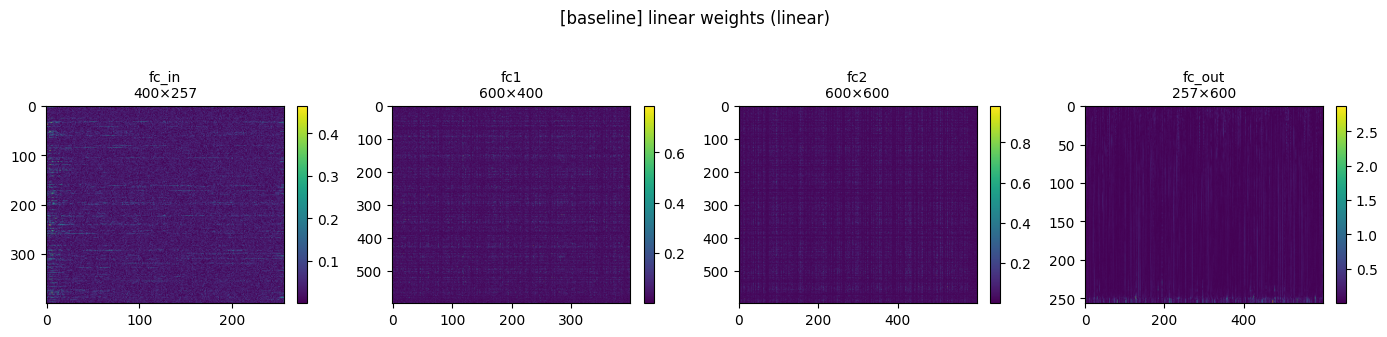

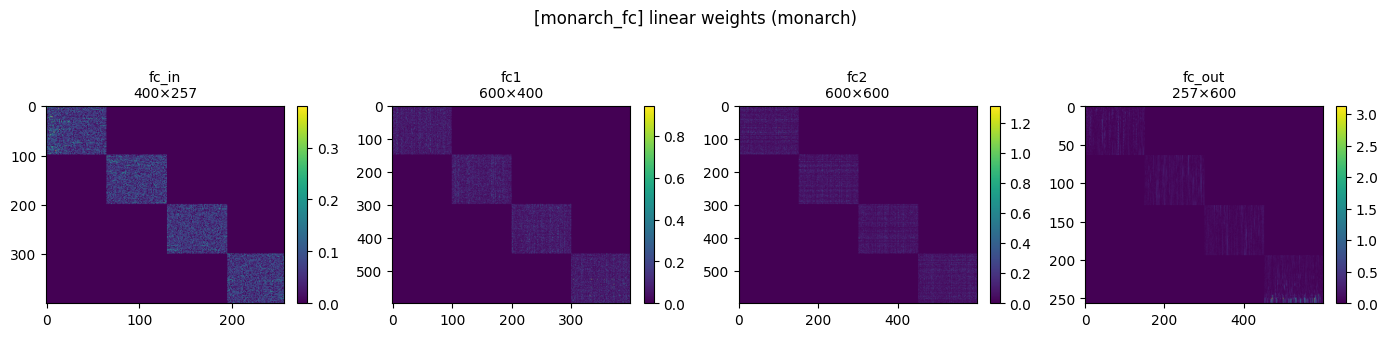

AssertionError: input must be contiguous (Pitfall 3)

In [6]:
def get_in_size(m):
    for attr in ('in_size', 'in_features'):
        if hasattr(m, attr):
            return getattr(m, attr)
    raise ValueError(f'unknown layer type: {type(m).__name__}')

@torch.no_grad()
def materialize_dense(module, in_size=None):
    in_size = in_size or get_in_size(module)
    eye = torch.eye(in_size, device=device)
    out = module(eye)
    if module.bias is not None:
        out = out - module.bias
    return out.T.detach().cpu().numpy()

def plot_grid(weight_dict, title=''):
    n = len(weight_dict)
    fig, axes = plt.subplots(1, n, figsize=(3.5 * n, 3.2))
    if n == 1:
        axes = [axes]
    for ax, (name, W) in zip(axes, weight_dict.items()):
        im = ax.imshow(np.abs(W), aspect='auto', cmap='viridis')
        ax.set_title(f'{name}\n{W.shape[0]}×{W.shape[1]}', fontsize=10)
        plt.colorbar(im, ax=ax, fraction=0.046)
    if title:
        fig.suptitle(title, y=1.04)
    plt.tight_layout()
    plt.show()

for name, run in runs.items():
    m = run['model']
    weights = {
        'fc_in':  materialize_dense(m.fc_in),
        'fc1':    materialize_dense(m.fc1),
        'fc2':    materialize_dense(m.fc2),
        'fc_out': materialize_dense(m.fc_out),
    }
    plot_grid(weights, title=f'[{name}] linear weights ({m.linear_kind})')

## GRU weight structure

Per layer, `W_ih` and `W_hh` are stacked across the 3 GRU gates (reset, update, new), so each is `(3 * hidden, in)`.

- **`nn.GRU`**: dense weights pulled directly from `weight_ih_l{k}` / `weight_hh_l{k}`.
- **`StructuredGRU`**: dense-equivalents of each cell's `x_proj` (W_ih) and `h_proj` (W_hh).

In [ ]:
def gru_weights(gru):
    out = {}
    if isinstance(gru, nn.GRU):
        for li in range(gru.num_layers):
            out[f'L{li} W_ih'] = getattr(gru, f'weight_ih_l{li}').detach().cpu().numpy()
            out[f'L{li} W_hh'] = getattr(gru, f'weight_hh_l{li}').detach().cpu().numpy()
    elif isinstance(gru, StructuredGRU):
        for li, cell in enumerate(gru.cells):
            out[f'L{li} W_ih'] = materialize_dense(cell.x_proj)
            out[f'L{li} W_hh'] = materialize_dense(cell.h_proj)
    else:
        raise TypeError(f'unknown gru type: {type(gru).__name__}')
    return out

for name, run in runs.items():
    plot_grid(gru_weights(run['model'].gru),
              title=f'[{name}] GRU weights ({run["model"].gru_kind})')

## Audio inference + spectrogram comparison

Pick a few VoiceBank-DEMAND test utterances, enhance with each model, then plot spectrograms (clean / noisy / one per model) and embed audio players.

Edit `EXAMPLE_IDX` to explore different utterances (test split has 824 items).

In [ ]:
hf = load_voicebank_demand()
test = hf['test']
print(f'test split: {len(test)} examples')

@torch.no_grad()
def enhance(model, h, noisy):
    wav = torch.FloatTensor(noisy).to(device)
    norm = torch.sqrt(len(wav) / (torch.sum(wav ** 2.0) + 1e-8))
    wav = (wav * norm).unsqueeze(0)
    amp, pha, _ = mag_pha_stft(wav, h.n_fft, h.hop_size, h.win_size, h.compress_factor)
    amp_g, pha_g, _ = model(amp, pha)
    audio_g = mag_pha_istft(amp_g, pha_g, h.n_fft, h.hop_size, h.win_size, h.compress_factor)
    return (audio_g / norm).squeeze().cpu().numpy()

def stft_db(audio, n_fft=400, hop=100):
    S = np.abs(librosa.stft(audio, n_fft=n_fft, hop_length=hop, win_length=n_fft))
    return 20.0 * np.log10(S + 1e-7)

In [ ]:
EXAMPLE_IDX = [0, 50, 200]

for idx in EXAMPLE_IDX:
    item = test[idx]
    clean = np.asarray(item['clean']['array'], dtype=np.float32)
    noisy = np.asarray(item['noisy']['array'], dtype=np.float32)
    print(f'\n=== test[{idx}]  id={item["id"]}  ({len(clean)/16000:.1f}s) ===')

    enhanced = {n: enhance(r['model'], r['h'], noisy) for n, r in runs.items()}

    # spectrograms
    audios = [('clean', clean), ('noisy', noisy)] + list(enhanced.items())
    n = len(audios)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.2), sharey=True)
    vmax = stft_db(clean).max()
    for ax, (label, aud) in zip(axes, audios):
        S = stft_db(aud)
        ax.imshow(S, aspect='auto', origin='lower', cmap='magma',
                  vmin=vmax - 80, vmax=vmax)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel('time frame')
    axes[0].set_ylabel('freq bin')
    plt.tight_layout()
    plt.show()

    # audio players
    print('Clean:'); ipd.display(ipd.Audio(clean, rate=16000))
    print('Noisy:'); ipd.display(ipd.Audio(noisy, rate=16000))
    for name, aud in enhanced.items():
        print(f'{name}:'); ipd.display(ipd.Audio(aud, rate=16000))